In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Softmax Regression

In [2]:
df = pd.read_csv("./API_LR.csv")
df.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_current_mA,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,class,confidence,inference_time_ms,batch
0,5/1/2026 10:35,53,69,39.6,51,-448,0,0.000000,0.000000,1,23,Compute-Heavy Activity,0.986009,243.539218,1
1,5/1/2026 10:35,35,69,39.6,51,-186,0,0.930182,0.000000,1,23,Low Activity,0.990687,1108.066979,1
2,5/1/2026 10:35,28,69,39.6,51,-146,0,0.160734,0.208347,1,23,Low Activity,0.985610,383.981197,1
3,5/1/2026 10:35,26,69,39.6,51,-136,0,0.258074,0.156298,1,23,Low Activity,0.992833,161.146718,1
4,5/1/2026 10:35,26,69,39.6,51,-109,0,0.160663,0.100415,1,23,Low Activity,0.995855,118.775625,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12168 entries, 0 to 12167
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            12168 non-null  str    
 1   cpu_usage            12168 non-null  int64  
 2   memory_usage         12168 non-null  int64  
 3   temperature          12168 non-null  float64
 4   battery_level        12168 non-null  int64  
 5   battery_current_mA   12168 non-null  int64  
 6   battery_charging     12168 non-null  int64  
 7   upload_speed_kbps    12168 non-null  float64
 8   download_speed_kbps  12168 non-null  float64
 9   screen_on            12168 non-null  int64  
 10  brightness           12168 non-null  int64  
 11  class                12168 non-null  str    
 12  confidence           12168 non-null  float64
 13  inference_time_ms    12168 non-null  float64
 14  batch                12168 non-null  int64  
dtypes: float64(5), int64(8), str(2)
memory usage: 1

### Data Cleaning

In [4]:
df.drop(df[df['confidence'] == -1].index, inplace=True)
df_cleaned = df.dropna()
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 12168 entries, 0 to 12167
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            12168 non-null  str    
 1   cpu_usage            12168 non-null  int64  
 2   memory_usage         12168 non-null  int64  
 3   temperature          12168 non-null  float64
 4   battery_level        12168 non-null  int64  
 5   battery_current_mA   12168 non-null  int64  
 6   battery_charging     12168 non-null  int64  
 7   upload_speed_kbps    12168 non-null  float64
 8   download_speed_kbps  12168 non-null  float64
 9   screen_on            12168 non-null  int64  
 10  brightness           12168 non-null  int64  
 11  class                12168 non-null  str    
 12  confidence           12168 non-null  float64
 13  inference_time_ms    12168 non-null  float64
 14  batch                12168 non-null  int64  
dtypes: float64(5), int64(8), str(2)
memory usage: 1

In [5]:
df_cleaned.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_current_mA,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,class,confidence,inference_time_ms,batch
0,5/1/2026 10:35,53,69,39.6,51,-448,0,0.000000,0.000000,1,23,Compute-Heavy Activity,0.986009,243.539218,1
1,5/1/2026 10:35,35,69,39.6,51,-186,0,0.930182,0.000000,1,23,Low Activity,0.990687,1108.066979,1
2,5/1/2026 10:35,28,69,39.6,51,-146,0,0.160734,0.208347,1,23,Low Activity,0.985610,383.981197,1
3,5/1/2026 10:35,26,69,39.6,51,-136,0,0.258074,0.156298,1,23,Low Activity,0.992833,161.146718,1
4,5/1/2026 10:35,26,69,39.6,51,-109,0,0.160663,0.100415,1,23,Low Activity,0.995855,118.775625,1


### Analysis

In [6]:
print(df_cleaned['class'].value_counts())

class
Low Activity              6513
Network Activity          4202
Compute-Heavy Activity    1453
Name: count, dtype: int64


In [7]:
result_analysis = df_cleaned.drop(columns=['battery_level','battery_charging','screen_on','brightness','timestamp', 'confidence', 'inference_time_ms', 'batch']).groupby('class').agg(['mean'])
df_analysis = result_analysis.reset_index()
df_analysis.head()

,class,cpu_usage,memory_usage,temperature,battery_current_mA,upload_speed_kbps,download_speed_kbps
,,mean,mean,mean,mean,mean,mean
0,Compute-Heavy Activity,58.299381,72.409498,37.233035,-396.429456,3.016495,9.499570
1,Low Activity,37.254721,71.029326,37.512529,423.669123,2.582533,4.544557
2,Network Activity,49.108044,72.169681,37.466921,-264.448596,12.166785,384.036788


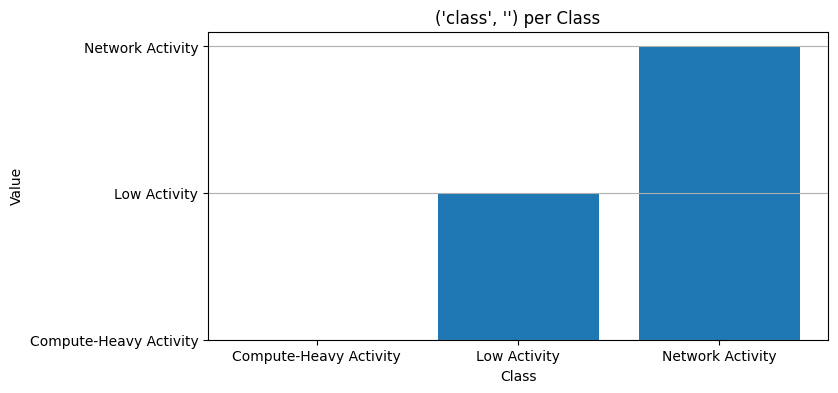

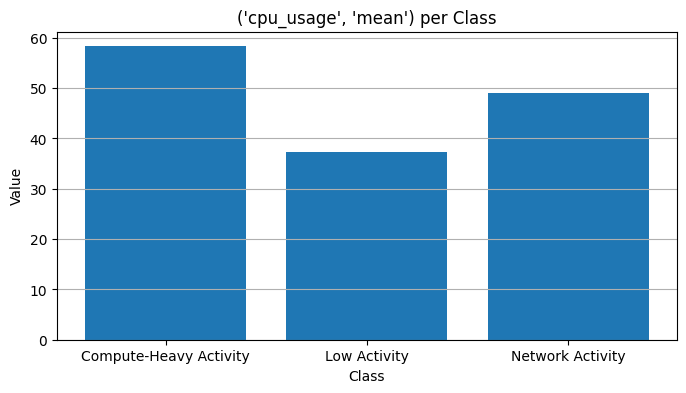

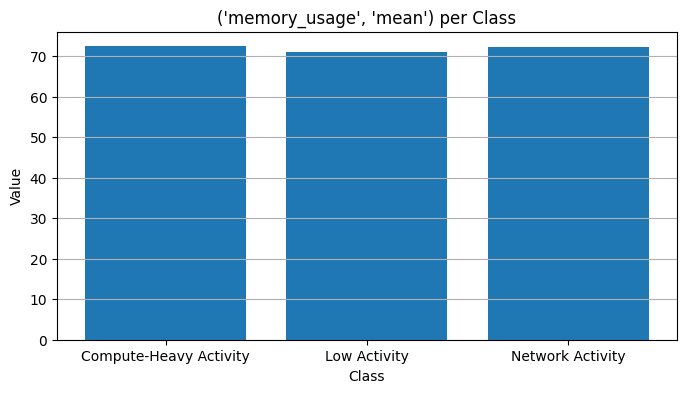

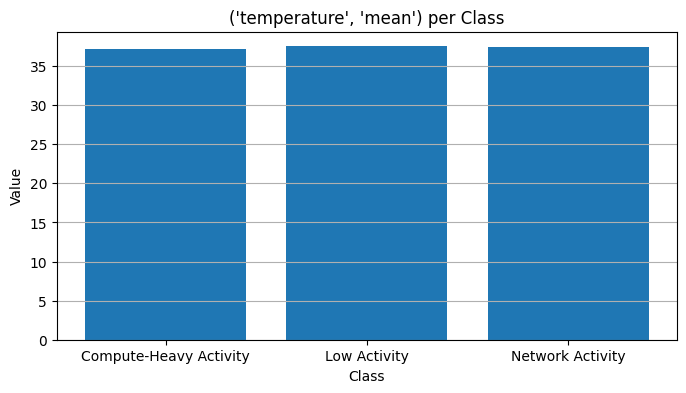

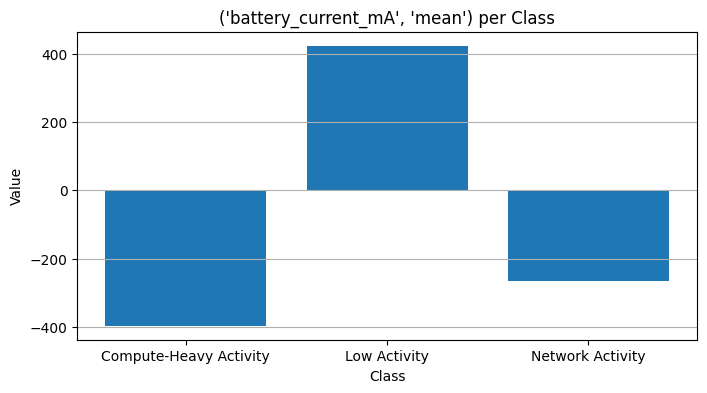

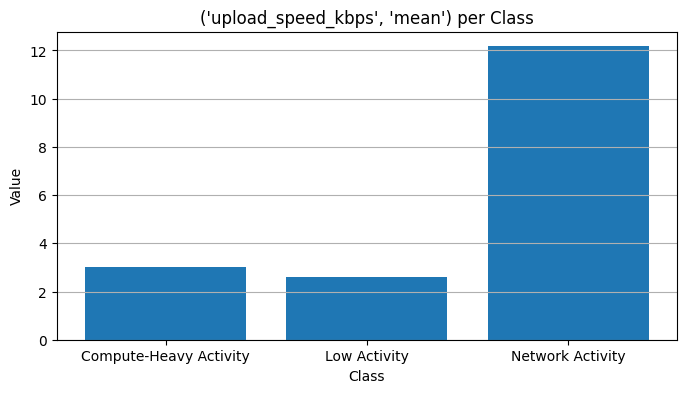

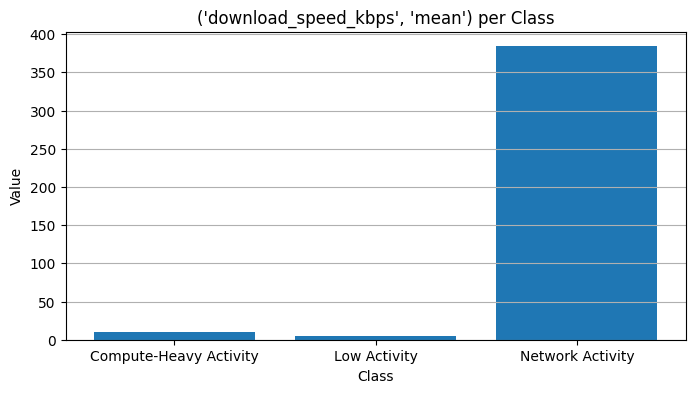

In [8]:
for col in df_analysis.columns:
    if col != 'class':
        plt.figure(figsize=(8, 4))
        plt.bar(df_analysis['class'], df_analysis[col])
        plt.title(f"{col} per Class")
        plt.xlabel("Class")
        plt.ylabel("Value")
        plt.grid(axis='y')
        plt.show()

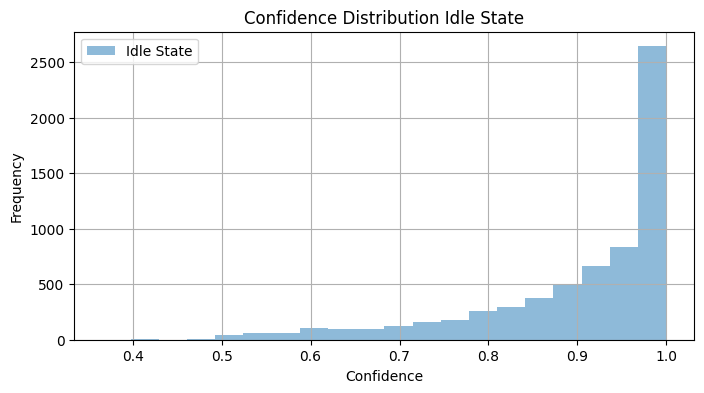

In [9]:
# Confidence Histogram Per Class
class_idle = df_cleaned[df_cleaned['class'] == 'Low Activity']['confidence']
class_compute = df_cleaned[df_cleaned['class'] == 'Compute-Heavy Activity']['confidence']
class_network = df_cleaned[df_cleaned['class'] == 'Network Activity']['confidence']

plt.figure(figsize=(8, 4))
plt.hist(class_idle, bins=20, alpha=0.5, label='Idle State')

plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution Idle State")
plt.legend()
plt.grid(True)
plt.show()

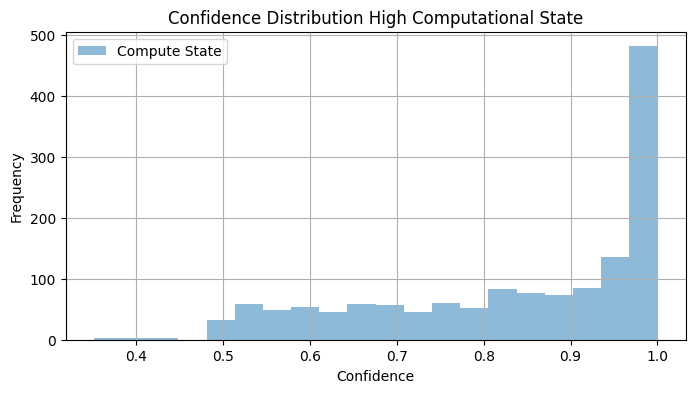

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(class_compute, bins=20, alpha=0.5, label='Compute State')
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution High Computational State")
plt.legend()
plt.grid(True)

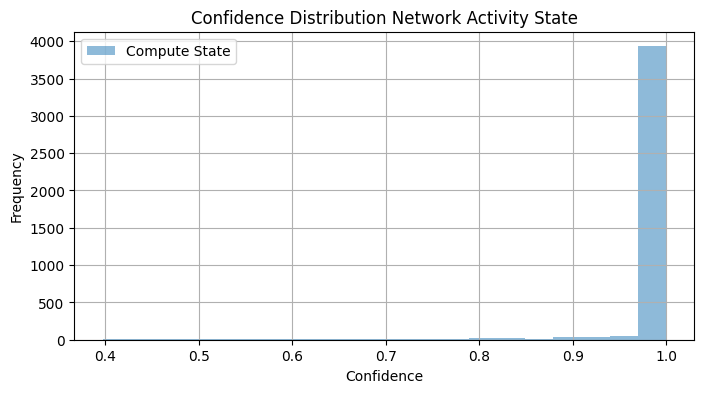

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(class_network, bins=20, alpha=0.5, label='Compute State')
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution Network Activity State")
plt.legend()
plt.grid(True)

In [12]:
# Inference
df_cleaned['inference_time_ms'].describe()

count    12168.000000
mean       203.406999
std        235.897407
min         88.284948
25%        126.280390
50%        163.464479
75%        223.229441
max      11903.947080
Name: inference_time_ms, dtype: float64

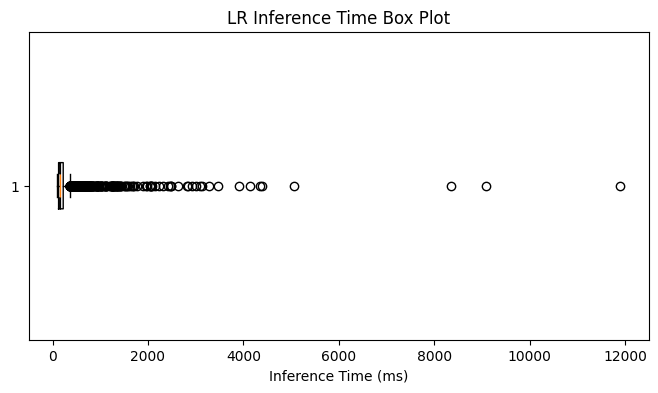

In [13]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_cleaned['inference_time_ms'], notch=True, vert=False)
plt.title("LR Inference Time Box Plot")
plt.xlabel("Inference Time (ms)")
plt.show()

## ANN

In [14]:
df_ann = pd.read_csv("./API_ANN.csv")
df_ann.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_current_mA,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,class,confidence,inference_time_ms,batch
0,4/30/2026 10:06,45,66,33.2,84,-166,0,0.000000,0.000000,1,24,Low Activity,0.999995,731.201145,1
1,4/30/2026 10:06,34,66,33.2,84,-227,0,0.543021,0.131133,1,24,Low Activity,0.999997,209.796666,1
2,4/30/2026 10:06,35,65,33.2,84,-296,0,5.946164,124.691490,1,24,Network Activity,0.999999,147.783073,1
3,4/30/2026 10:06,36,65,33.2,84,-270,0,0.731633,0.296634,1,24,Low Activity,0.999989,202.428594,1
4,4/30/2026 10:06,35,66,33.2,84,-222,0,0.936257,0.312247,1,24,Low Activity,0.999998,311.011145,1


In [15]:
df_ann.info()

<class 'pandas.DataFrame'>
RangeIndex: 9253 entries, 0 to 9252
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            9253 non-null   str    
 1   cpu_usage            9253 non-null   int64  
 2   memory_usage         9253 non-null   int64  
 3   temperature          9253 non-null   float64
 4   battery_level        9253 non-null   int64  
 5   battery_current_mA   9253 non-null   int64  
 6   battery_charging     9253 non-null   int64  
 7   upload_speed_kbps    9253 non-null   float64
 8   download_speed_kbps  9253 non-null   float64
 9   screen_on            9253 non-null   int64  
 10  brightness           9253 non-null   int64  
 11  class                9253 non-null   str    
 12  confidence           9253 non-null   float64
 13  inference_time_ms    9253 non-null   float64
 14  batch                9253 non-null   int64  
dtypes: float64(5), int64(8), str(2)
memory usage: 1.1

### Data Cleaning

In [16]:
df_ann.drop(df_ann[df_ann['confidence'] == -1].index, inplace=True)
df_ann_cleaned = df_ann.dropna()
df_ann_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 9253 entries, 0 to 9252
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            9253 non-null   str    
 1   cpu_usage            9253 non-null   int64  
 2   memory_usage         9253 non-null   int64  
 3   temperature          9253 non-null   float64
 4   battery_level        9253 non-null   int64  
 5   battery_current_mA   9253 non-null   int64  
 6   battery_charging     9253 non-null   int64  
 7   upload_speed_kbps    9253 non-null   float64
 8   download_speed_kbps  9253 non-null   float64
 9   screen_on            9253 non-null   int64  
 10  brightness           9253 non-null   int64  
 11  class                9253 non-null   str    
 12  confidence           9253 non-null   float64
 13  inference_time_ms    9253 non-null   float64
 14  batch                9253 non-null   int64  
dtypes: float64(5), int64(8), str(2)
memory usage: 1.1

In [17]:
df_ann_cleaned.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_current_mA,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,class,confidence,inference_time_ms,batch
0,4/30/2026 10:06,45,66,33.2,84,-166,0,0.000000,0.000000,1,24,Low Activity,0.999995,731.201145,1
1,4/30/2026 10:06,34,66,33.2,84,-227,0,0.543021,0.131133,1,24,Low Activity,0.999997,209.796666,1
2,4/30/2026 10:06,35,65,33.2,84,-296,0,5.946164,124.691490,1,24,Network Activity,0.999999,147.783073,1
3,4/30/2026 10:06,36,65,33.2,84,-270,0,0.731633,0.296634,1,24,Low Activity,0.999989,202.428594,1
4,4/30/2026 10:06,35,66,33.2,84,-222,0,0.936257,0.312247,1,24,Low Activity,0.999998,311.011145,1


### Analysis

In [18]:
print(df_ann_cleaned['class'].value_counts())

class
Low Activity              3792
Network Activity          3619
Compute-Heavy Activity    1842
Name: count, dtype: int64


In [19]:
result_analysis_ann = df_ann_cleaned.drop(
    columns=['battery_level', 'battery_charging', 'screen_on', 'brightness', 'timestamp', 'confidence',
             'inference_time_ms', 'batch']).groupby('class').agg(['mean'])
df_analysis_ann = result_analysis_ann.reset_index()
df_analysis_ann.head()

,class,cpu_usage,memory_usage,temperature,battery_current_mA,upload_speed_kbps,download_speed_kbps
,,mean,mean,mean,mean,mean,mean
0,Compute-Heavy Activity,52.007058,73.140608,34.920358,-351.775244,15.036086,292.716540
1,Low Activity,38.325949,70.554852,34.874631,-236.600475,2.248266,2.833401
2,Network Activity,45.955513,71.951644,36.032854,161.960486,6.393077,92.792193


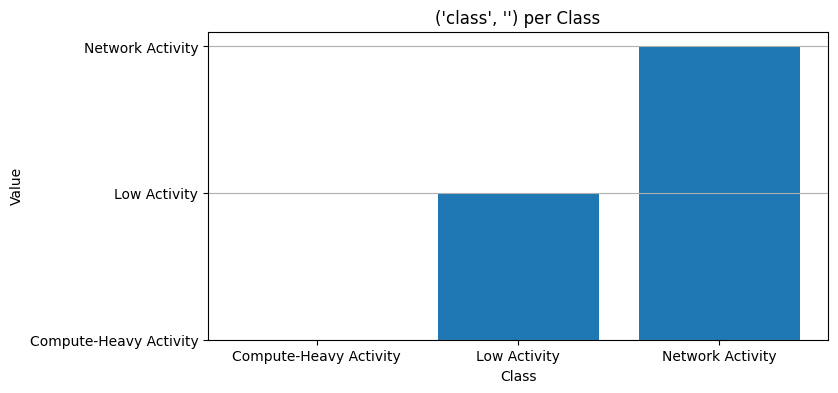

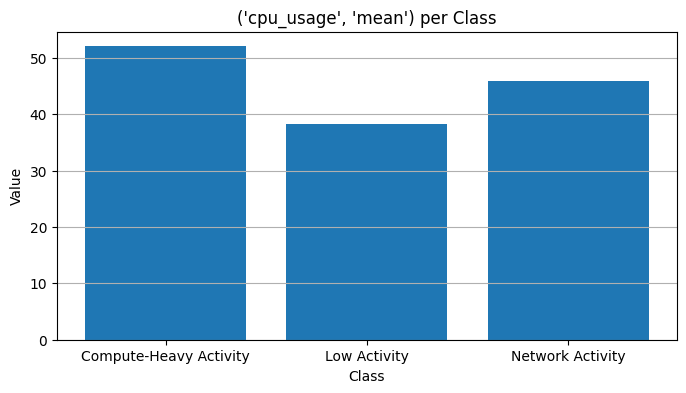

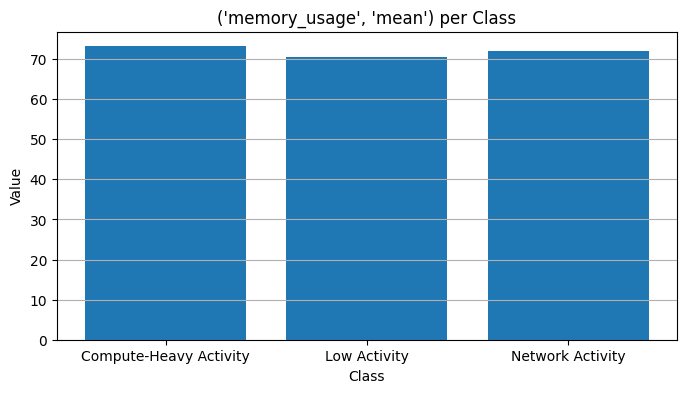

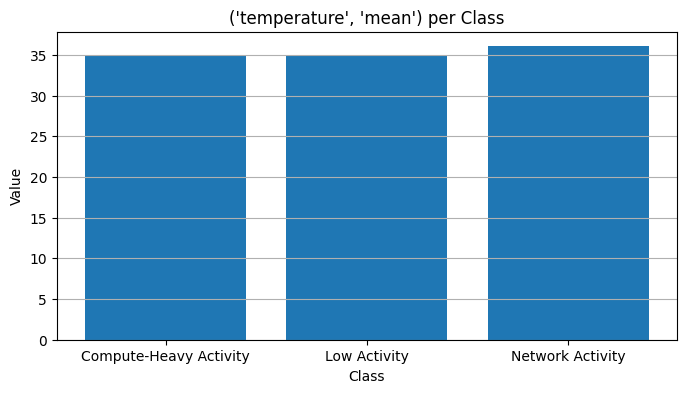

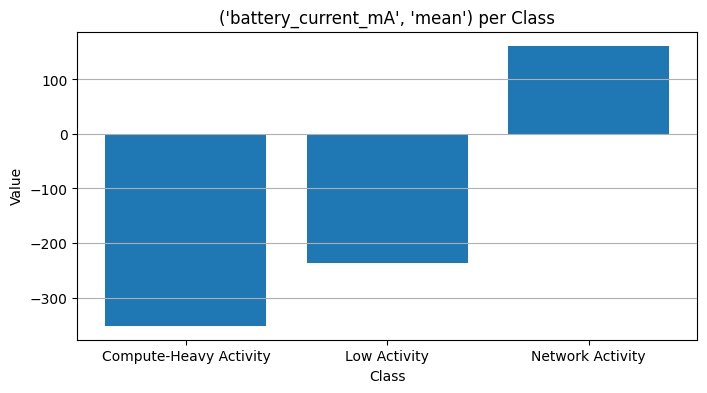

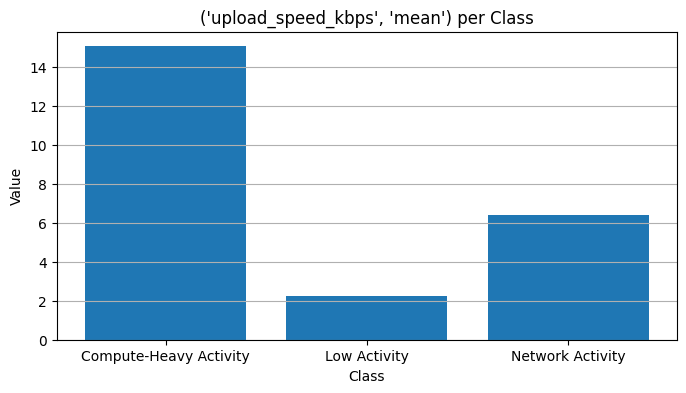

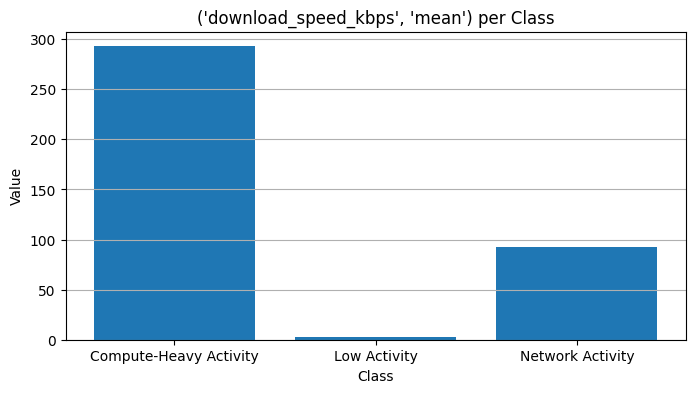

In [20]:
for col in df_analysis_ann.columns:
    if col != 'class':
        plt.figure(figsize=(8, 4))
        plt.bar(df_analysis_ann['class'], df_analysis_ann[col])
        plt.title(f"{col} per Class")
        plt.xlabel("Class")
        plt.ylabel("Value")
        plt.grid(axis='y')
        plt.show()

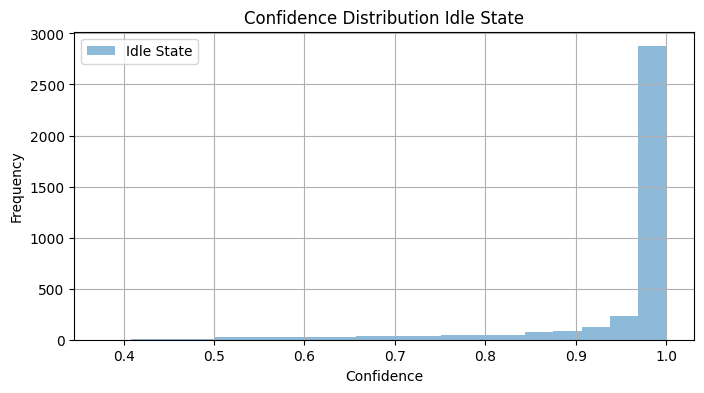

In [21]:
# Confidence Histogram Per Class
class_idle = df_ann_cleaned[df_ann_cleaned['class'] == 'Low Activity']['confidence']
class_compute = df_ann_cleaned[df_ann_cleaned['class'] == 'Compute-Heavy Activity']['confidence']
class_network = df_ann_cleaned[df_ann_cleaned['class'] == 'Network Activity']['confidence']

plt.figure(figsize=(8, 4))
plt.hist(class_idle, bins=20, alpha=0.5, label='Idle State')

plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution Idle State")
plt.legend()
plt.grid(True)
plt.show()

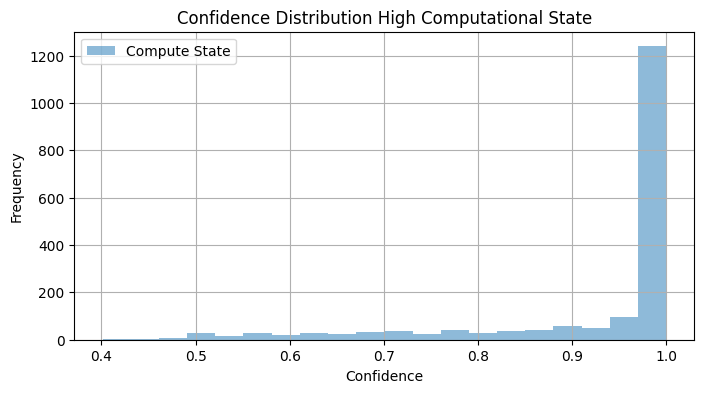

In [22]:
plt.figure(figsize=(8, 4))
plt.hist(class_compute, bins=20, alpha=0.5, label='Compute State')
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution High Computational State")
plt.legend()
plt.grid(True)

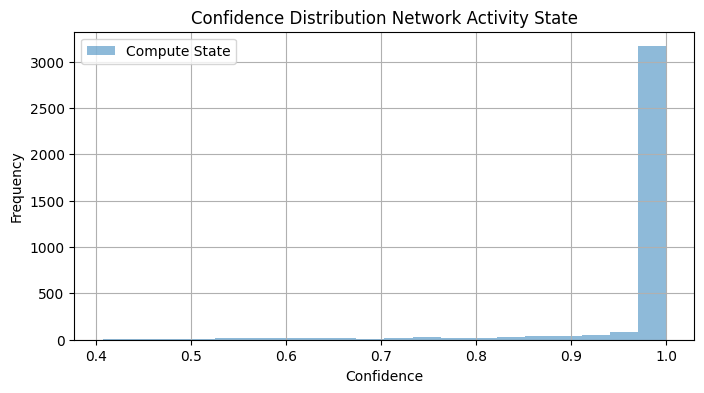

In [23]:
plt.figure(figsize=(8, 4))
plt.hist(class_network, bins=20, alpha=0.5, label='Compute State')
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution Network Activity State")
plt.legend()
plt.grid(True)

In [24]:
# Inference
df_ann_cleaned['inference_time_ms'].describe()

count    9253.000000
mean      185.017154
std       189.095485
min        74.411927
25%       127.658594
50%       159.433229
75%       206.373854
max      8179.491664
Name: inference_time_ms, dtype: float64

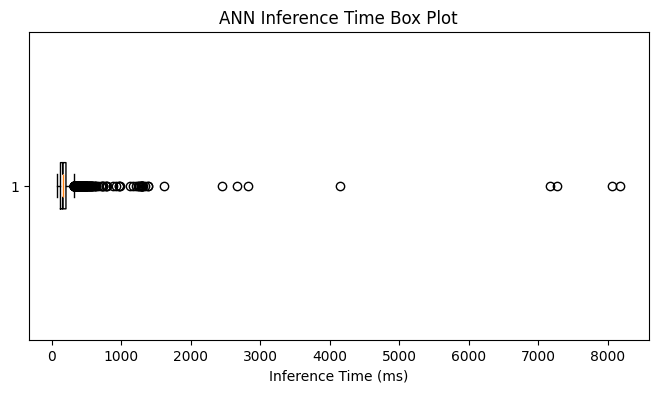

In [25]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_ann_cleaned['inference_time_ms'], notch=True, vert=False)
plt.title("ANN Inference Time Box Plot")
plt.xlabel("Inference Time (ms)")
plt.show()